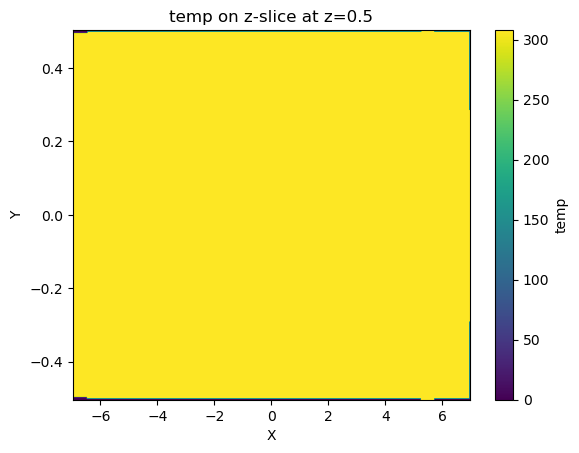

In [1]:
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt

mesh = pv.read("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/wall/results/wall_3.vtk")

z0 = .5
sl = mesh.slice(normal="z", origin=(0, 0, z0))

# x0 = 2  # pick an x inside mesh.bounds
# sl = mesh.slice(normal="x", origin=(x0, 0, 0))
# y0 = 1  # pick an x inside mesh.bounds
# sl = mesh.slice(normal="y", origin=(0, y0, 0))

# Ensure temp is point data on the slice
if "temp" not in sl.point_data:
    if "temp" in sl.cell_data:
        sl = sl.cell_data_to_point_data()
    else:
        raise ValueError("temp not found in slice.")

# Define a uniform 2D grid in XY at z=z0
nx, ny = 800, 250
xmin, xmax, ymin, ymax = sl.bounds[0], sl.bounds[1], sl.bounds[2], sl.bounds[3]

x = np.linspace(xmin, xmax, nx)
y = np.linspace(ymin, ymax, ny)
xx, yy = np.meshgrid(x, y)

# Build a point cloud grid (nx*ny points) at constant z0
pts = np.c_[xx.ravel(), yy.ravel(), np.full(xx.size, z0)]
grid = pv.PolyData(pts)

# Sample temperature from the slice onto the grid
sampled = grid.sample(sl)

temp = sampled["temp"].reshape(ny, nx)

# Values with no data become 0 or NaN depending on VTK; mask zeros if needed:
# temp = np.where(temp == 0, np.nan, temp)

plt.figure()
plt.imshow(
    temp,
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    aspect="auto",
)
plt.colorbar(label="temp")
plt.title(f"temp on z-slice at z={z0}")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [12]:
import pyvista as pv
import numpy as np

# mesh = pv.read("wall_1.vtk")
mesh = pv.read("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/wall/results/wall_3.vtk")

print("point_data:", mesh.point_data.keys())
print("cell_data :", mesh.cell_data.keys())
print("field_data:", mesh.field_data.keys())

# Promote field_data arrays (length == n_points) to point_data
for name in mesh.field_data.keys():
    arr = mesh.field_data[name]
    # handle (n,) or (n,1)
    arr = np.asarray(arr)
    if arr.shape[0] == mesh.n_points:
        mesh.point_data[name] = arr.reshape(mesh.n_points, -1)[:, 0] if arr.ndim == 2 and arr.shape[1] == 1 else arr

# Now these should work as point scalars:
# mesh.point_data["S_von"], mesh.point_data["S11"], etc.

point_data: ['temp', 'S_von', 'S11', 'S22', 'S33', 'S12', 'S23', 'S13', 'U1', 'U2', 'U3']
cell_data : []
field_data: []


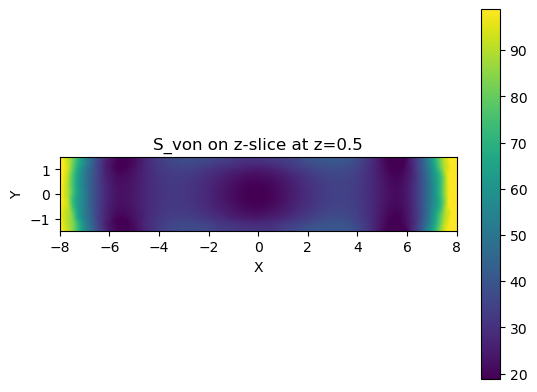

In [ ]:
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt

def slice_plane_to_grids(mesh, axis, value, scalars="S_von", n1=800, n2=250, mask_invalid=True):
    if scalars not in mesh.point_data:
        raise ValueError(f'"{scalars}" not in point_data. Available: {list(mesh.point_data.keys())}')

    xmin, xmax, ymin, ymax, zmin, zmax = mesh.bounds
    axis = axis.lower()

    if axis == "z":
        center = (0.5*(xmin+xmax), 0.5*(ymin+ymax), value)
        direction = (0, 0, 1)
        i_size, j_size = (xmax-xmin), (ymax-ymin)  # x by y
        nx, ny = n1, n2
        xlab, ylab = "X", "Y"
    elif axis == "x":
        center = (value, 0.5*(ymin+ymax), 0.5*(zmin+zmax))
        direction = (1, 0, 0)
        i_size, j_size = (ymax-ymin), (zmax-zmin)  # y by z
        nx, ny = n1, n2
        xlab, ylab = "Y", "Z"
    elif axis == "y":
        center = (0.5*(xmin+xmax), value, 0.5*(zmin+zmax))
        direction = (0, 1, 0)
        i_size, j_size = (xmax-xmin), (zmax-zmin)  # x by z
        nx, ny = n1, n2
        xlab, ylab = "X", "Z"
    else:
        raise ValueError("axis must be 'x', 'y', or 'z'")

    plane = pv.Plane(
        center=center,
        direction=direction,
        i_size=i_size,
        j_size=j_size,
        i_resolution=nx-1,
        j_resolution=ny-1,
    )

    sampled = plane.sample(mesh)

    # Key: C-order reshape for plane samples (avoids stripe artifact)
    pts = sampled.points.reshape((ny, nx, 3), order="C")
    X, Y, Z = pts[:, :, 0], pts[:, :, 1], pts[:, :, 2]
    V = sampled[scalars].reshape((ny, nx), order="C")

    valid = None
    if "vtkValidPointMask" in sampled.point_data:
        valid = sampled["vtkValidPointMask"].reshape((ny, nx), order="C").astype(bool)
        if mask_invalid:
            V = np.where(valid, V, np.nan)

    return X, Y, Z, V, valid, (xlab, ylab)

def plot_slice(X, Y, V, xlab="X", ylab="Y", title="", robust=True):
    fig, ax = plt.subplots()
    m = np.isfinite(V)

    # Optional robust color scaling (helps when values are almost constant)
    if robust and np.any(m):
        vmin, vmax = np.nanpercentile(V, [2, 98])
    else:
        vmin, vmax = None, None

    pcm = ax.pcolormesh(X, Y, V, shading="auto", vmin=vmin, vmax=vmax)
    fig.colorbar(pcm, ax=ax)

    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")

    # Auto-zoom to valid region
    if np.any(m):
        ax.set_xlim(X[m].min(), X[m].max())
        ax.set_ylim(Y[m].min(), Y[m].max())

    plt.show()

# Example usage
mesh = pv.read("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/wall/results/wall_3.vtk")

X, Y, Z, V, valid, (xlab, ylab) = slice_plane_to_grids(mesh, axis="z", value=-4, scalars="S_von", n1=800, n2=250)
plot_slice(X, Y, V, xlab=xlab, ylab=ylab, title="S_von on z-slice at z=0.5")

X, Y, Z, V, valid, (xlab, ylab) = slice_plane_to_grids(mesh, axis="z", value=-4, scalars="S_von", n1=800, n2=250)
plot_slice(X, Y, V, xlab=xlab, ylab=ylab, title="S_von on z-slice at z=0.5")

/tmp/ipykernel_757288/3827689015.py:77: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(X[m].min(), X[m].max())


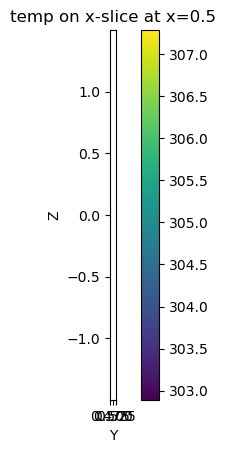

In [21]:
X, Y, Z, V, valid, labs = slice_plane_to_grids(mesh, "x", 0.5, scalars="temp")
xlab, ylab = labs
plot_slice(X, Y, V, xlab=xlab, ylab=ylab, title="temp on x-slice at x=0.5")

In [36]:
import numpy as np
import pyvista as pv


class DEDVTK:
    """
    Convenience class for DED solver VTK outputs.

    Common fields (often):
      - temp
      - S_von, S11, S22, S33, S12, S23, S13
      - U1, U2, U3

    Features:
      - slice_plane(axis, value, scalars, ...) -> structured grids + values
      - plot_slice(...) and plot_slice_index(...) for quick visualization
      - volume_average(scalars) -> volume-weighted average (fallback to point-mean)
      - summaries_for_bo(...) -> dictionary of common metrics
      - resample_to_volume(...) -> uniform 3D volume for fast numpy slicing
    """

    def __init__(self, vtk_path: str):
        self.vtk_path = vtk_path
        self.mesh = pv.read(vtk_path)
        self._promote_field_data()

    # ---------- basic info ----------
    @property
    def bounds(self):
        return self.mesh.bounds  # (xmin, xmax, ymin, ymax, zmin, zmax)

    @property
    def point_fields(self):
        return list(self.mesh.point_data.keys())

    @property
    def cell_fields(self):
        return list(self.mesh.cell_data.keys())

    def has(self, name: str) -> bool:
        return (name in self.mesh.point_data) or (name in self.mesh.cell_data) or (name in self.mesh.field_data)

    # ---------- internal helpers ----------
    def _promote_field_data(self):
        """
        If arrays are stored in field_data, promote them to point_data or cell_data
        when their first dimension matches n_points or n_cells.
        """
        for name in list(self.mesh.field_data.keys()):
            arr = np.asarray(self.mesh.field_data[name])
            if arr.ndim == 2 and arr.shape[1] == 1:
                arr = arr[:, 0]
            if arr.ndim >= 1 and arr.shape[0] == self.mesh.n_points:
                self.mesh.point_data[name] = arr
            elif arr.ndim >= 1 and arr.shape[0] == self.mesh.n_cells:
                self.mesh.cell_data[name] = arr

    def _ensure_point_scalar(self, scalars: str) -> pv.DataSet:
        """
        Return a mesh where `scalars` is available in point_data.
        If only cell_data exists, convert cell->point.
        """
        if scalars in self.mesh.point_data:
            return self.mesh
        if scalars in self.mesh.cell_data:
            return self.mesh.cell_data_to_point_data()
        raise ValueError(f'"{scalars}" not found. point={self.point_fields}, cell={self.cell_fields}')

    # ---------- slicing (structured plane) ----------
    def slice_plane(
        self,
        axis: str,
        value: float,
        scalars: str = "temp",
        n1: int = 800,
        n2: int = 250,
        pad: float = 0.0,
        mask_invalid: bool = True,
    ):
        """
        Sample onto a structured plane and return:
          (X, Y, Z, V, valid_mask, (xlabel, ylabel))

        axis='x' returns a Y-Z plane at x=value
        axis='y' returns an X-Z plane at y=value
        axis='z' returns an X-Y plane at z=value

        IMPORTANT: Uses order='C' reshape (prevents stripe/barcode artifacts).
        """
        mesh = self._ensure_point_scalar(scalars)

        xmin, xmax, ymin, ymax, zmin, zmax = mesh.bounds
        xmin -= pad; xmax += pad
        ymin -= pad; ymax += pad
        zmin -= pad; zmax += pad

        axis = axis.lower().strip()
        if axis == "z":
            center = (0.5 * (xmin + xmax), 0.5 * (ymin + ymax), value)
            direction = (0.0, 0.0, 1.0)
            i_size, j_size = (xmax - xmin), (ymax - ymin)
            nx, ny = n1, n2
            xlabel, ylabel = "X", "Y"
        elif axis == "x":
            center = (value, 0.5 * (ymin + ymax), 0.5 * (zmin + zmax))
            direction = (1.0, 0.0, 0.0)
            i_size, j_size = (ymax - ymin), (zmax - zmin)
            nx, ny = n1, n2
            xlabel, ylabel = "Y", "Z"
        elif axis == "y":
            center = (0.5 * (xmin + xmax), value, 0.5 * (zmin + zmax))
            direction = (0.0, 1.0, 0.0)
            i_size, j_size = (xmax - xmin), (zmax - zmin)
            nx, ny = n1, n2
            xlabel, ylabel = "X", "Z"
        else:
            raise ValueError("axis must be one of: 'x', 'y', 'z'")

        plane = pv.Plane(
            center=center,
            direction=direction,
            i_size=i_size,
            j_size=j_size,
            i_resolution=nx - 1,
            j_resolution=ny - 1,
        )

        sampled = plane.sample(mesh)

        # vtkPlaneSource ordering -> reshape with C-order
        pts = sampled.points.reshape((ny, nx, 3), order="C")
        X = pts[:, :, 0]
        Y = pts[:, :, 1]
        Z = pts[:, :, 2]

        V = sampled[scalars].reshape((ny, nx), order="C")

        if "vtkValidPointMask" in sampled.point_data:
            valid = sampled["vtkValidPointMask"].reshape((ny, nx), order="C").astype(bool)
        else:
            valid = np.ones((ny, nx), dtype=bool)

        if mask_invalid:
            V = np.where(valid, V, np.nan)

        return X, Y, Z, V, valid, (xlabel, ylabel)

    # ---------- visualization helpers ----------
    def plot_slice(
        self,
        axis: str,
        value: float,
        scalars: str = "temp",
        n1: int = 800,
        n2: int = 250,
        pad: float = 0.0,
        mask_invalid: bool = True,
        robust: bool = True,
        cmap: str | None = None,
        title: str | None = None,
        show: bool = True,
        ax=None,
    ):
        """
        Plot a scalar on a plane slice using matplotlib.

        Returns:
          (fig, ax, (X, Y, Z, V, valid, (xlabel, ylabel)))
        """
        import matplotlib.pyplot as plt

        X, Y, Z, V, valid, (xlabel, ylabel) = self.slice_plane(
            axis=axis,
            value=value,
            scalars=scalars,
            n1=n1,
            n2=n2,
            pad=pad,
            mask_invalid=mask_invalid,
        )

        axis_l = axis.lower().strip()
        if axis_l == "x":
            A, B = Y, Z  # Y-Z plane
            xlab, ylab = "Y", "Z"
        elif axis_l == "y":
            A, B = X, Z  # X-Z plane
            xlab, ylab = "X", "Z"
        else:
            A, B = X, Y  # X-Y plane
            xlab, ylab = "X", "Y"

        m = np.isfinite(V)
        vmin = vmax = None
        if robust and np.any(m):
            vmin, vmax = np.nanpercentile(V, [2, 98])

        if ax is None:
            fig, ax = plt.subplots()
        else:
            fig = ax.figure

        pcm = ax.pcolormesh(A, B, V, shading="auto", vmin=vmin, vmax=vmax, cmap=cmap)
        fig.colorbar(pcm, ax=ax, label=scalars)

        ax.set_xlabel(xlab)
        ax.set_ylabel(ylab)
        ax.set_aspect("equal", adjustable="box")

        if title is None:
            title = f"{scalars} on {axis_l}-slice at {axis_l}={value}"
        ax.set_title(title)

        # Auto-zoom to valid region
        if np.any(m):
            ax.set_xlim(A[m].min(), A[m].max())
            ax.set_ylim(B[m].min(), B[m].max())

        if show:
            plt.show()

        return fig, ax, (X, Y, Z, V, valid, (xlabel, ylabel))

    def _axis_value_from_index(self, axis: str, index: int, n: int = 200) -> float:
        """
        Map an index in [0, n-1] to a coordinate value uniformly within mesh bounds.
        """
        xmin, xmax, ymin, ymax, zmin, zmax = self.bounds
        axis_l = axis.lower().strip()
        index = int(np.clip(index, 0, n - 1))
        if axis_l == "x":
            return float(np.linspace(xmin, xmax, n)[index])
        if axis_l == "y":
            return float(np.linspace(ymin, ymax, n)[index])
        if axis_l == "z":
            return float(np.linspace(zmin, zmax, n)[index])
        raise ValueError("axis must be 'x', 'y', or 'z'")

    def plot_slice_index(
        self,
        axis: str,
        index: int,
        scalars: str = "temp",
        index_grid_n: int = 200,
        n1: int = 800,
        n2: int = 250,
        pad: float = 0.0,
        mask_invalid: bool = True,
        robust: bool = True,
        cmap: str | None = None,
        title: str | None = None,
        show: bool = True,
        ax=None,
    ):
        """
        Plot a slice using an index instead of a coordinate.
        Index is mapped uniformly across bounds (not by actual node layers).
        """
        idx = int(np.clip(index, 0, index_grid_n - 1))
        value = self._axis_value_from_index(axis, idx, n=index_grid_n)

        if title is None:
            title = f"{scalars} on {axis.lower()}-slice index {idx} (coord {value:.4g})"

        return self.plot_slice(
            axis=axis,
            value=value,
            scalars=scalars,
            n1=n1,
            n2=n2,
            pad=pad,
            mask_invalid=mask_invalid,
            robust=robust,
            cmap=cmap,
            title=title,
            show=show,
            ax=ax,
        )

    # ---------- averages for BO ----------
    def volume_average(self, scalars: str, ignore_nan: bool = True) -> float:
        """
        Volume-weighted average of `scalars` over the whole mesh.
        Falls back to point-mean if volume calculation fails.
        """
        try:
            # Work in cell space for volume weights
            if scalars in self.mesh.point_data and scalars not in self.mesh.cell_data:
                m = self.mesh.point_data_to_cell_data(pass_point_data=False)
            else:
                m = self.mesh.copy()

            if scalars not in m.cell_data:
                m = m.point_data_to_cell_data(pass_point_data=False)

            m = m.compute_cell_sizes(volume=True)
            vols = np.asarray(m.cell_data["Volume"])
            vals = np.asarray(m.cell_data[scalars])

            if ignore_nan:
                ok = np.isfinite(vals) & np.isfinite(vols) & (vols > 0)
                vols, vals = vols[ok], vals[ok]

            return float(np.sum(vals * vols) / np.sum(vols))
        except Exception:
            mesh = self._ensure_point_scalar(scalars)
            vals = np.asarray(mesh.point_data[scalars])
            if ignore_nan:
                vals = vals[np.isfinite(vals)]
            return float(np.mean(vals))

    def summaries_for_bo(self, stress_scalar: str = "S_von") -> dict:
        """
        Summary metrics you can log per VTK file for your BO loop.
        """
        out = {
            "vtk_path": self.vtk_path,
            "temp_avg": self.volume_average("temp") if self.has("temp") else None,
            "temp_max": float(np.nanmax(np.asarray(self._ensure_point_scalar("temp").point_data["temp"]))) if self.has("temp") else None,
            "stress_avg": self.volume_average(stress_scalar) if self.has(stress_scalar) else None,
            "stress_max": float(np.nanmax(np.asarray(self._ensure_point_scalar(stress_scalar).point_data[stress_scalar]))) if self.has(stress_scalar) else None,
        }
        return out

    # ---------- optional: uniform volume for fast numpy slicing ----------
    def resample_to_volume(
        self,
        scalars: str = "temp",
        nx: int = 220,
        ny: int = 120,
        nz: int = 120,
        pad: float = 0.0,
        mask_invalid: bool = True,
    ):
        """
        Resample an unstructured mesh to a uniform ImageData volume.

        Returns:
          V_zyx, x, y, z, valid_zyx
          - V_zyx has shape (nz, ny, nx)
          - x, y, z are 1D axes arrays

        Ideal for many slices with pure NumPy indexing:
          V_xy = V_zyx[k, :, :]  (z-slice)
        """
        mesh = self._ensure_point_scalar(scalars)

        xmin, xmax, ymin, ymax, zmin, zmax = mesh.bounds
        xmin -= pad; xmax += pad
        ymin -= pad; ymax += pad
        zmin -= pad; zmax += pad

        dx = (xmax - xmin) / (nx - 1)
        dy = (ymax - ymin) / (ny - 1)
        dz = (zmax - zmin) / (nz - 1)

        vol = pv.ImageData(
            dimensions=(nx, ny, nz),
            spacing=(dx, dy, dz),
            origin=(xmin, ymin, zmin),
        )

        sampled = vol.sample(mesh)

        # ImageData stored with x fastest, then y, then z (Fortran reshape)
        V_xyz = sampled[scalars].reshape((nx, ny, nz), order="F")
        V_zyx = np.transpose(V_xyz, (2, 1, 0))  # (z, y, x)

        if "vtkValidPointMask" in sampled.point_data:
            valid_xyz = sampled["vtkValidPointMask"].reshape((nx, ny, nz), order="F").astype(bool)
            valid_zyx = np.transpose(valid_xyz, (2, 1, 0))
        else:
            valid_zyx = np.ones_like(V_zyx, dtype=bool)

        if mask_invalid:
            V_zyx = np.where(valid_zyx, V_zyx, np.nan)

        x = xmin + dx * np.arange(nx)
        y = ymin + dy * np.arange(ny)
        z = zmin + dz * np.arange(nz)

        return V_zyx, x, y, z, valid_zyx

/tmp/ipykernel_757288/3830736332.py:203: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(A, B, V, shading="auto", vmin=vmin, vmax=vmax, cmap=cmap)


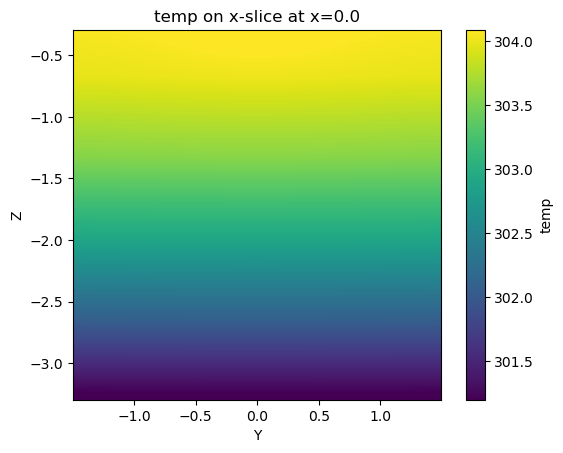

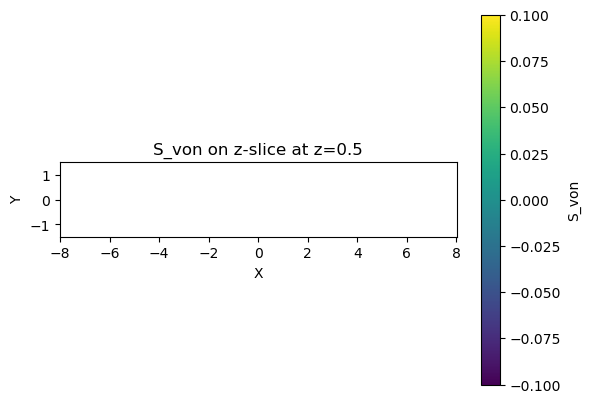

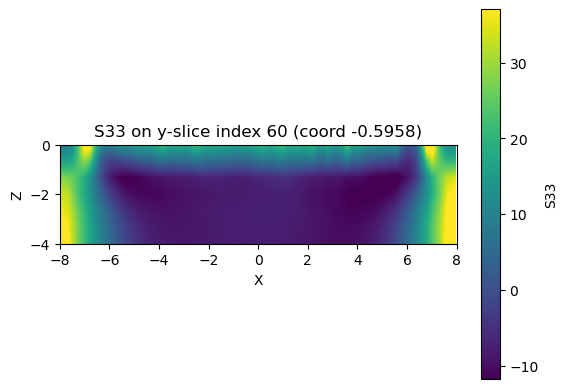

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'S33 on y-slice index 60 (coord -0.5958)'}, xlabel='X', ylabel='Z'>,
 (pyvista_ndarray([[-8.       , -7.9799747, -7.95995  , ...,  7.95995  ,
                     7.9799747,  8.       ],
                   [-8.       , -7.9799747, -7.95995  , ...,  7.95995  ,
                     7.9799747,  8.       ],
                   [-8.       , -7.9799747, -7.95995  , ...,  7.95995  ,
                     7.9799747,  8.       ],
                   ...,
                   [-8.       , -7.9799747, -7.95995  , ...,  7.95995  ,
                     7.9799747,  8.       ],
                   [-8.       , -7.9799747, -7.95995  , ...,  7.95995  ,
                     7.9799747,  8.       ],
                   [-8.       , -7.9799747, -7.95995  , ...,  7.95995  ,
                     7.9799747,  8.       ]], dtype=float32),
  pyvista_ndarray([[-0.59581697, -0.59581697, -0.59581697, ...,
                    -0.59581697, -0.59581697, -0.59581697

In [42]:
d = DEDVTK("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/wall/results/wall_1.vtk")

# Temperature at x = midpoint of bounds
xmin, xmax, ymin, ymax, zmin, zmax = d.bounds
x0 = 0.5*(xmin + xmax)
d.plot_slice(axis="x", value=x0, scalars="temp")
# Von Mises stress at z = 0.5
d.plot_slice(axis="z", value=0.5, scalars="S_von")
# Stress component S33 at y-index = 60 (index mapped over bounds)
d.plot_slice_index(axis="y", index=60, scalars="S33", index_grid_n=200)

Max S_von: 822.523


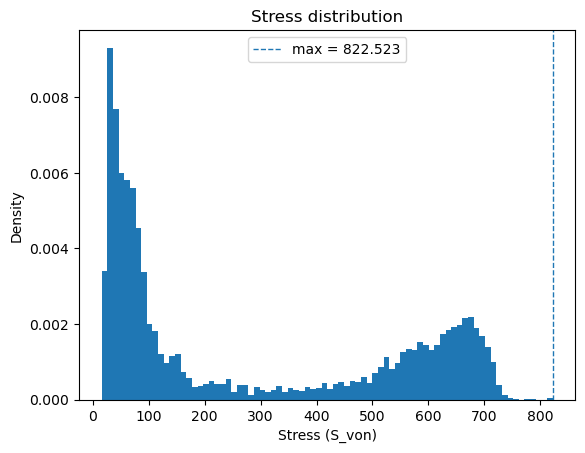

Max temp: 308.049


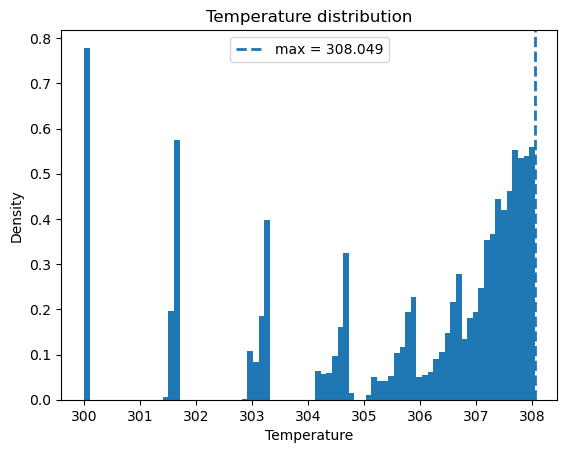

In [69]:
import numpy as np
import matplotlib.pyplot as plt

d = DEDVTK("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/wall/results/wall_3.vtk")

stress = np.asarray(d.mesh.point_data["S_von"])
stress = stress[np.isfinite(stress)]

smax = float(np.max(stress))
print(f"Max S_von: {smax:.6g}")

plt.figure()
plt.hist(stress, bins=80, density=True)   # density=True matches your y-label
plt.axvline(smax, linestyle="--", linewidth=1, label=f"max = {smax:.6g}")
plt.xlabel("Stress (S_von)")
plt.ylabel("Density")
plt.title("Stress distribution")
plt.legend()
plt.show()

temp = np.asarray(d.mesh.point_data["temp"])
temp = temp[np.isfinite(temp)]

tmax = float(np.max(temp))
print(f"Max temp: {tmax:.6g}")

plt.figure()
plt.hist(temp, bins=80, density=True)
plt.axvline(tmax, linestyle="--", linewidth=2, label=f"max = {tmax:.6g}")
plt.xlabel("Temperature")
plt.ylabel("Density")
plt.title("Temperature distribution")
plt.legend()
plt.show()

Max cell temp: 308.048


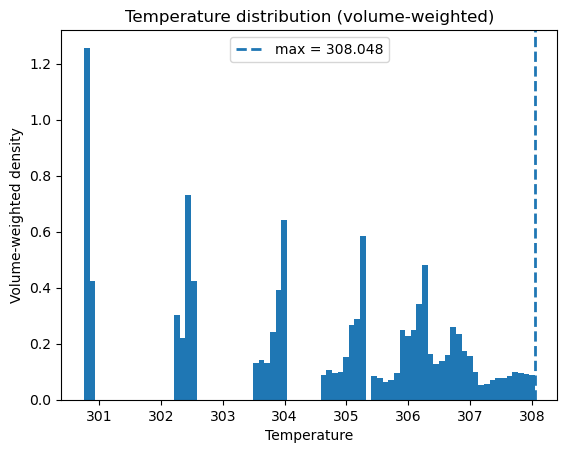

In [66]:
import numpy as np
import matplotlib.pyplot as plt

d = DEDVTK("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/wall/results/wall_3.vtk")

m = d.mesh
if "temp" in m.point_data and "temp" not in m.cell_data:
    m = m.point_data_to_cell_data(pass_point_data=False)

m = m.compute_cell_sizes(volume=True)
vals = np.asarray(m.cell_data["temp"])
w = np.asarray(m.cell_data["Volume"])

ok = np.isfinite(vals) & np.isfinite(w) & (w > 0)
vals, w = vals[ok], w[ok]

tmax = float(np.max(vals))
print(f"Max cell temp: {tmax:.6g}")

plt.figure()
plt.hist(vals, bins=80, weights=w, density=True)
plt.axvline(tmax, linestyle="--", linewidth=2, label=f"max = {tmax:.6g}")
plt.xlabel("Temperature")
plt.ylabel("Volume-weighted density")
plt.title("Temperature distribution (volume-weighted)")
plt.legend()
plt.show()

stress rank/shape: 4 (1843, 83270, 8, 6) dtype: dtype("float32")
temp   rank/shape: 2 (1843, 96874) dtype: dtype("float32")
time   rank/shape: 1 (1843,) dtype: dtype("float32")
[last frame] time = 42.996, max temp = 304.016


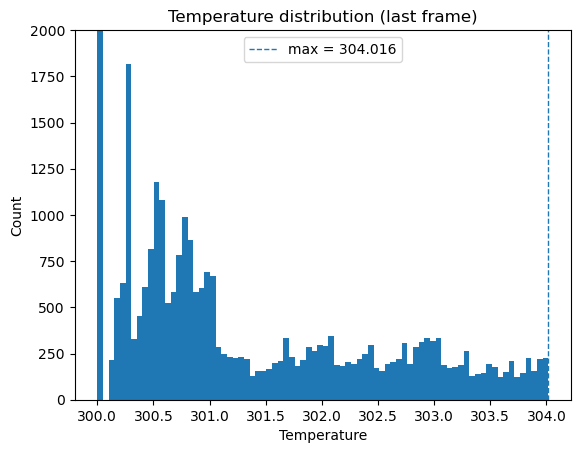

[last frame] time = 42.996, max von Mises (cell max over IPs) = 380.28


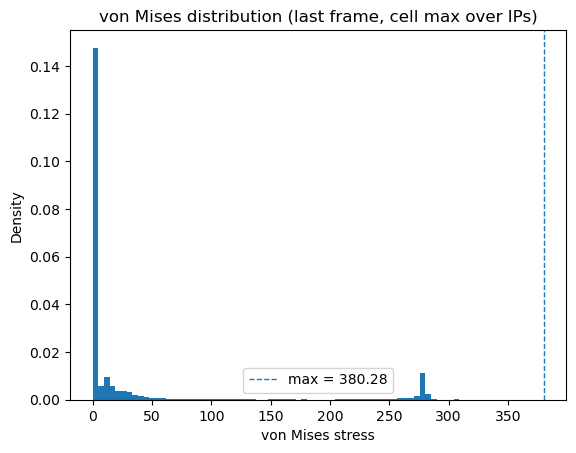

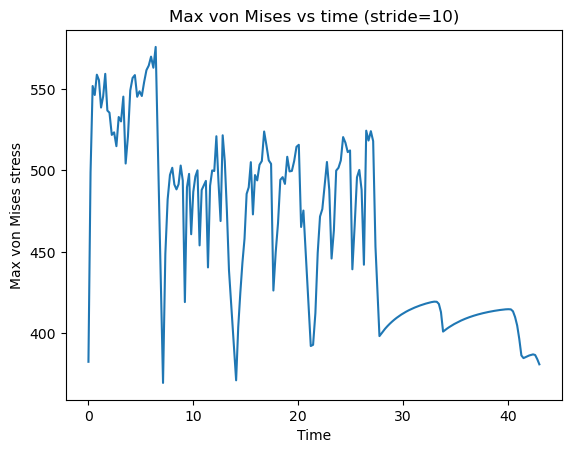

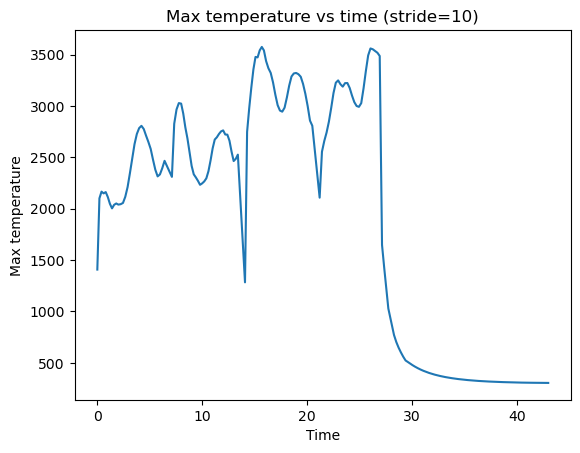

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorstore as ts

# ----------------------------
# Paths (EDIT IF NEEDED)
# ----------------------------
ZARR_DIR = Path(
    "/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/BOTSPO_Rep/stress_history_eval_0.zarr"
)

# Optional: a VTK file to provide geometry for 3D plots
VTK_GEOM = Path(
    "/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/wall/results/wall_0.vtk"
)

# ----------------------------
# TensorStore open helper
# ----------------------------
def open_zarr3_array(name: str):
    spec = {
        "driver": "zarr3",
        "kvstore": {"driver": "file", "path": str(ZARR_DIR)},
        "path": name,  # "stress", "temperature", "time", "U"
    }
    return ts.open(spec, open=True).result()

# ----------------------------
# Stress helper: von Mises
# ----------------------------
def von_mises_from_6(s6: np.ndarray) -> np.ndarray:
    """
    Compute von Mises from symmetric 3D stress components.
    Assumed ordering: [sxx, syy, szz, sxy, syz, sxz]
    Input: s6 shape (..., 6)
    Output: von Mises shape (...)
    """
    sxx = s6[..., 0]
    syy = s6[..., 1]
    szz = s6[..., 2]
    sxy = s6[..., 3]
    syz = s6[..., 4]
    sxz = s6[..., 5]
    return np.sqrt(
        0.5 * ((sxx - syy) ** 2 + (syy - szz) ** 2 + (szz - sxx) ** 2)
        + 3.0 * (sxy**2 + syz**2 + sxz**2)
    )

# ============================================================
# 1) Open arrays + print shapes
# ============================================================
stress_ts = open_zarr3_array("stress")
temp_ts   = open_zarr3_array("temperature")
time_ts   = open_zarr3_array("time")

print("stress rank/shape:", stress_ts.rank, stress_ts.shape, "dtype:", stress_ts.dtype)
print("temp   rank/shape:", temp_ts.rank,   temp_ts.shape,   "dtype:", temp_ts.dtype)
print("time   rank/shape:", time_ts.rank,   time_ts.shape,   "dtype:", time_ts.dtype)

t = np.asarray(time_ts.read().result()).reshape(-1)
nt = int(t.shape[0])

# IMPORTANT: TensorStore does NOT support negative indexing like [-1]
i_last = nt - 1

# ============================================================
# 2) Last-frame temperature histogram
# ============================================================
temp_last = np.asarray(temp_ts[i_last].read().result()).reshape(-1)
temp_last = temp_last[np.isfinite(temp_last)]
tmax = float(temp_last.max())
print(f"[last frame] time = {t[i_last]:.6g}, max temp = {tmax:.6g}")

plt.figure()
plt.hist(temp_last, bins=80)
plt.axvline(tmax, linestyle="--", linewidth=1, label=f"max = {tmax:.6g}")
plt.ylim(top=2000)  # start y-axis at 0
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.title("Temperature distribution (last frame)")
plt.legend()
plt.show()

# ============================================================
# 3) Last-frame stress -> von Mises (cell-based) histogram
#    stress shape: (n_cells, 8, 6) at one time step
#    reduce 8 integration points -> one scalar per cell (max or mean)
# ============================================================
stress_last = np.asarray(stress_ts[i_last].read().result())   # (n_cells, 8, 6)
stress_last = np.where(np.isfinite(stress_last), stress_last, np.nan)

vm_ip = von_mises_from_6(stress_last)         # (n_cells, 8)
vm_cell_max  = np.nanmax(vm_ip, axis=1)       # (n_cells,)
vm_cell_mean = np.nanmean(vm_ip, axis=1)      # (n_cells,)

# choose which to plot: "max" tends to match safety/envelope thinking
vm = vm_cell_max
vm = vm[np.isfinite(vm)]
smax = float(vm.max())
print(f"[last frame] time = {t[i_last]:.6g}, max von Mises (cell max over IPs) = {smax:.6g}")

plt.figure()
plt.hist(vm, bins=80, density=True)
plt.axvline(smax, linestyle="--", linewidth=1, label=f"max = {smax:.6g}")
plt.xlabel("von Mises stress")
plt.ylabel("Density")
plt.title("von Mises distribution (last frame, cell max over IPs)")
plt.legend()
plt.show()

# ============================================================
# 4) Max vs time (stress + temperature)
#    Tip: start with stride=10 to make it faster.
# ============================================================
stride = 10  # set to 1 for full resolution (slower)
idxs = np.arange(0, nt, stride)

smax_t = np.empty_like(idxs, dtype=float)
tmax_t = np.empty_like(idxs, dtype=float)

for k, i in enumerate(idxs):
    # max temperature at time i
    Ti = np.asarray(temp_ts[i].read().result()).reshape(-1)
    tmax_t[k] = np.nanmax(Ti)

    # max von Mises at time i
    Si = np.asarray(stress_ts[i].read().result())  # (n_cells, 8, 6)
    Si = np.where(np.isfinite(Si), Si, np.nan)
    vmi = von_mises_from_6(Si)                     # (n_cells, 8)
    vm_cell = np.nanmax(vmi, axis=1)               # (n_cells,)
    smax_t[k] = np.nanmax(vm_cell)

plt.figure()
plt.plot(t[idxs], smax_t)
plt.xlabel("Time")
plt.ylabel("Max von Mises stress")
plt.title(f"Max von Mises vs time (stride={stride})")
plt.show()

plt.figure()
plt.plot(t[idxs], tmax_t)
plt.xlabel("Time")
plt.ylabel("Max temperature")
plt.title(f"Max temperature vs time (stride={stride})")
plt.show()


In [6]:
from pathlib import Path
import numpy as np
import tensorstore as ts

# pip install meshio if needed:
# !python -m pip install meshio
import meshio

# ----------------------------
# Paths
# ----------------------------
EVAL_DIR = Path("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/BOTSPO_Rep")
ZARR_DIR = EVAL_DIR / "stress_history_eval_1.zarr"
K_FILE   = EVAL_DIR / "wall.k"

TIME_INDEX = None     # None -> last
IP_REDUCTION = "max"  # "max" or "mean"

# ----------------------------
# TensorStore open helper
# ----------------------------
def open_zarr3_array(name: str):
    spec = {
        "driver": "zarr3",
        "kvstore": {"driver": "file", "path": str(ZARR_DIR)},
        "path": name,
    }
    return ts.open(spec, open=True).result()

# ----------------------------
# von Mises from 6 comps
# assumed ordering: [sxx, syy, szz, sxy, syz, sxz]
# ----------------------------
def von_mises_from_6(s6: np.ndarray) -> np.ndarray:
    sxx = s6[..., 0]
    syy = s6[..., 1]
    szz = s6[..., 2]
    sxy = s6[..., 3]
    syz = s6[..., 4]
    sxz = s6[..., 5]
    return np.sqrt(
        0.5 * ((sxx - syy) ** 2 + (syy - szz) ** 2 + (szz - sxx) ** 2)
        + 3.0 * (sxy**2 + syz**2 + sxz**2)
    )

# ----------------------------
# Parse LS-DYNA keyword file: *NODE and *ELEMENT_SOLID (hex8)
# ----------------------------
def parse_lsdyna_k_nodes_hex8(k_path: Path):
    if not k_path.exists():
        raise FileNotFoundError(f"Could not find K file: {k_path}")

    nodes = {}      # nid -> (x,y,z)
    elements = []   # list of 8 node ids per element (in file order)

    section = None
    pending = None  # (eid, node_ids_collected)

    def clean(line: str) -> str:
        if "$" in line:
            line = line.split("$", 1)[0]
        return line.strip()

    with k_path.open("r", errors="ignore") as f:
        for raw in f:
            line = clean(raw)
            if not line:
                continue

            if line.startswith("*"):
                key = line.upper().split()[0]
                if key.startswith("*NODE"):
                    section = "NODE"
                elif key.startswith("*ELEMENT_SOLID"):
                    section = "E_SOLID"
                else:
                    section = None
                pending = None
                continue

            if section == "NODE":
                parts = line.split()
                if len(parts) < 4:
                    continue
                try:
                    nid = int(float(parts[0]))
                    x = float(parts[1]); y = float(parts[2]); z = float(parts[3])
                    nodes[nid] = (x, y, z)
                except ValueError:
                    continue

            elif section == "E_SOLID":
                parts = line.split()
                if not parts:
                    continue

                nums = []
                for p in parts:
                    try:
                        nums.append(int(float(p)))
                    except ValueError:
                        pass

                if pending is None:
                    if len(nums) < 3:
                        continue
                    eid = nums[0]
                    node_ids = nums[2:]  # skip pid
                    pending = (eid, node_ids)
                else:
                    eid, node_ids = pending
                    node_ids = node_ids + nums
                    pending = (eid, node_ids)

                eid, node_ids = pending
                if len(node_ids) >= 8:
                    elements.append(node_ids[:8])
                    pending = None

    if len(nodes) == 0 or len(elements) == 0:
        raise RuntimeError(
            f"Parsed nodes={len(nodes)}, elements={len(elements)} from {k_path}. "
            "Check it contains *NODE and *ELEMENT_SOLID."
        )

    return nodes, elements

# ============================================================
# 1) Read arrays from Zarr
# ============================================================
stress_ts = open_zarr3_array("stress")        # (nt, n_cells, 8, 6)
temp_ts   = open_zarr3_array("temperature")   # (nt, n_points)
time_ts   = open_zarr3_array("time")          # (nt,)

t = np.asarray(time_ts.read().result()).reshape(-1)
nt = int(t.shape[0])
i = (nt - 1) if TIME_INDEX is None else int(TIME_INDEX)

print("Zarr:", ZARR_DIR)
print("stress:", stress_ts.shape)
print("temp  :", temp_ts.shape)
print("time  :", time_ts.shape)
print(f"Using time index i={i}, time={t[i]:.6g}")

temp_i = np.asarray(temp_ts[i].read().result()).reshape(-1)
temp_i = np.where(np.isfinite(temp_i), temp_i, np.nan)

stress_i = np.asarray(stress_ts[i].read().result())   # (n_cells, 8, 6)
stress_i = np.where(np.isfinite(stress_i), stress_i, np.nan)

vm_ip = von_mises_from_6(stress_i)  # (n_cells, 8)
vm_cell = np.nanmean(vm_ip, axis=1) if IP_REDUCTION.lower() == "mean" else np.nanmax(vm_ip, axis=1)

n_points_needed = temp_i.size
n_cells_needed  = vm_cell.size
print("Need mesh:", n_points_needed, "points,", n_cells_needed, "cells")

# ============================================================
# 2) Parse wall.k and build mesh arrays for meshio
# ============================================================
nodes, elements = parse_lsdyna_k_nodes_hex8(K_FILE)

node_ids_sorted = np.array(sorted(nodes.keys()), dtype=np.int64)
id_to_idx = {nid: j for j, nid in enumerate(node_ids_sorted)}

points = np.array([nodes[nid] for nid in node_ids_sorted], dtype=np.float64)

# connectivity: (n_cells, 8) with 0-based node indices
hex_conn = np.empty((len(elements), 8), dtype=np.int64)
for c, conn_ids in enumerate(elements):
    hex_conn[c, :] = [id_to_idx[nid] for nid in conn_ids]

print("Parsed wall.k:", points.shape[0], "points,", hex_conn.shape[0], "hex elements")

# sanity check with zarr sizes
assert points.shape[0] == n_points_needed, "wall.k node count != temperature node count"
assert hex_conn.shape[0] == n_cells_needed, "wall.k element count != stress cell count"

# ============================================================
# 3) Write VTU for ParaView/VisIt
# ============================================================
out_vtu = Path(f"eval0_t{i:04d}.vtu")

mesh = meshio.Mesh(
    points=points,
    cells=[("hexahedron", hex_conn)],
    point_data={"temperature": temp_i.astype(np.float32)},
    cell_data={"vm": [vm_cell.astype(np.float32)]},  # list per cell block
)

meshio.write(out_vtu, mesh)
print("Wrote:", out_vtu.resolve())

Zarr: /data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/BOTSPO_Rep/stress_history_eval_1.zarr
stress: (1843, 83270, 8, 6)
temp  : (1843, 96874)
time  : (1843,)
Using time index i=1842, time=42.996
Need mesh: 96874 points, 83270 cells
Parsed wall.k: 96874 points, 83270 hex elements
Wrote: /data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/ME 441/eval0_t1842.vtu


In [7]:
from pathlib import Path
import numpy as np
import tensorstore as ts
import meshio

EVAL_DIR = Path("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/BOTSPO_Rep")
ZARR_DIR = EVAL_DIR / "stress_history_eval_1.zarr"
K_FILE   = EVAL_DIR / "wall.k"

OUT_DIR = EVAL_DIR / "vtu_eval_1"
OUT_DIR.mkdir(exist_ok=True)

stride = 10  # 1 = every step (1843 files). Start with 10.
IP_REDUCTION = "max"  # "max" or "mean"

def open_zarr3_array(name: str):
    spec = {"driver":"zarr3","kvstore":{"driver":"file","path":str(ZARR_DIR)},"path":name}
    return ts.open(spec, open=True).result()

def von_mises_from_6(s6):
    sxx, syy, szz, sxy, syz, sxz = [s6[...,k] for k in range(6)]
    return np.sqrt(0.5*((sxx-syy)**2+(syy-szz)**2+(szz-sxx)**2) + 3.0*(sxy**2+syz**2+sxz**2))

# ---- parse wall.k once (your same parser) ----
def parse_lsdyna_k_nodes_hex8(k_path: Path):
    nodes = {}
    elements = []
    section = None
    pending = None
    def clean(line: str) -> str:
        if "$" in line:
            line = line.split("$", 1)[0]
        return line.strip()
    with k_path.open("r", errors="ignore") as f:
        for raw in f:
            line = clean(raw)
            if not line:
                continue
            if line.startswith("*"):
                key = line.upper().split()[0]
                if key.startswith("*NODE"):
                    section = "NODE"
                elif key.startswith("*ELEMENT_SOLID"):
                    section = "E_SOLID"
                else:
                    section = None
                pending = None
                continue
            if section == "NODE":
                parts = line.split()
                if len(parts) < 4:
                    continue
                nid = int(float(parts[0]))
                nodes[nid] = (float(parts[1]), float(parts[2]), float(parts[3]))
            elif section == "E_SOLID":
                nums = []
                for p in line.split():
                    try: nums.append(int(float(p)))
                    except: pass
                if pending is None:
                    if len(nums) < 3: 
                        continue
                    eid = nums[0]
                    node_ids = nums[2:]
                    pending = (eid, node_ids)
                else:
                    eid, node_ids = pending
                    node_ids = node_ids + nums
                    pending = (eid, node_ids)
                eid, node_ids = pending
                if len(node_ids) >= 8:
                    elements.append(node_ids[:8])
                    pending = None
    return nodes, elements

nodes, elements = parse_lsdyna_k_nodes_hex8(K_FILE)
node_ids_sorted = np.array(sorted(nodes.keys()), dtype=np.int64)
id_to_idx = {nid: j for j, nid in enumerate(node_ids_sorted)}
points = np.array([nodes[nid] for nid in node_ids_sorted], dtype=np.float64)

hex_conn = np.empty((len(elements), 8), dtype=np.int64)
for c, conn_ids in enumerate(elements):
    hex_conn[c, :] = [id_to_idx[nid] for nid in conn_ids]

# ---- open zarr arrays ----
stress_ts = open_zarr3_array("stress")
temp_ts   = open_zarr3_array("temperature")
time_ts   = open_zarr3_array("time")

t = np.asarray(time_ts.read().result()).reshape(-1)
nt = t.size

# ---- export loop ----
for i in range(0, nt, stride):
    temp_i = np.asarray(temp_ts[i].read().result()).reshape(-1)
    temp_i = np.where(np.isfinite(temp_i), temp_i, np.nan)

    stress_i = np.asarray(stress_ts[i].read().result())  # (n_cells, 8, 6)
    stress_i = np.where(np.isfinite(stress_i), stress_i, np.nan)

    vm_ip = von_mises_from_6(stress_i)
    vm_cell = np.nanmean(vm_ip, axis=1) if IP_REDUCTION == "mean" else np.nanmax(vm_ip, axis=1)

    out_vtu = OUT_DIR / f"eval1_t{i:04d}.vtu"
    mesh = meshio.Mesh(
        points=points,
        cells=[("hexahedron", hex_conn)],
        point_data={"temperature": temp_i.astype(np.float32)},
        cell_data={"vm": [vm_cell.astype(np.float32)]},
    )
    meshio.write(out_vtu, mesh)

print("Wrote series to:", OUT_DIR)

Wrote series to: /data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/BOTSPO_Rep/vtu_eval_1


In [9]:
from pathlib import Path
import numpy as np
import tensorstore as ts
import meshio

# ============================================================
# Export Zarr(v3) -> VTU time series for VisIt/ParaView
# - Uses wall.k to build a HEX mesh (ID-based, robust ordering)
# - Writes eval1_t0000.vtu, eval1_t0010.vtu, ...
# - Also writes times.txt (index, physical time)
# ============================================================

# ----------------------------
# Paths / settings
# ----------------------------
EVAL_DIR = Path("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/BOTSPO_Rep")
ZARR_DIR = EVAL_DIR / "stress_history_eval_1.zarr"
K_FILE   = EVAL_DIR / "wall.k"

OUT_DIR = EVAL_DIR / "vtu_eval_1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

stride = 10                 # 1 = every step (1843 files). Start with 10.
IP_REDUCTION = "max"         # "max" or "mean"
EVAL_TAG = "eval1"           # filename prefix

# ----------------------------
# TensorStore open helper
# ----------------------------
def open_zarr3_array(zarr_dir: Path, name: str):
    spec = {
        "driver": "zarr3",
        "kvstore": {"driver": "file", "path": str(zarr_dir)},
        "path": name,
    }
    return ts.open(spec, open=True).result()

# ----------------------------
# von Mises from 6 stress comps
# assumed ordering: [sxx, syy, szz, sxy, syz, sxz]
# ----------------------------
def von_mises_from_6(s6: np.ndarray) -> np.ndarray:
    sxx = s6[..., 0]
    syy = s6[..., 1]
    szz = s6[..., 2]
    sxy = s6[..., 3]
    syz = s6[..., 4]
    sxz = s6[..., 5]
    return np.sqrt(
        0.5 * ((sxx - syy) ** 2 + (syy - szz) ** 2 + (szz - sxx) ** 2)
        + 3.0 * (sxy**2 + syz**2 + sxz**2)
    )

# ----------------------------
# Fast ID-based parser for YOUR wall.k
# - assumes node ids: 1..n_nodes
# - assumes elem ids: 1..n_elems
# - reads *NODE and *ELEMENT_SOLID (8-node hex)
# ----------------------------
def parse_wall_k_id_based(k_path: Path, n_nodes: int, n_elems: int):
    if not k_path.exists():
        raise FileNotFoundError(f"Could not find K file: {k_path}")

    points = np.empty((n_nodes, 3), dtype=np.float64)
    hex_conn = np.empty((n_elems, 8), dtype=np.int64)

    in_node = False
    in_elem = False

    def clean(line: str) -> str:
        if "$" in line:
            line = line.split("$", 1)[0]
        return line.strip()

    with k_path.open("r", errors="ignore") as f:
        for raw in f:
            line = clean(raw)
            if not line:
                continue

            if line.startswith("*"):
                up = line.upper().split()[0]
                in_node = up.startswith("*NODE")
                in_elem = up.startswith("*ELEMENT_SOLID")
                continue

            if in_node:
                parts = line.split()
                if len(parts) < 4:
                    continue
                nid = int(float(parts[0]))
                # store at nid-1
                points[nid - 1, 0] = float(parts[1])
                points[nid - 1, 1] = float(parts[2])
                points[nid - 1, 2] = float(parts[3])

            elif in_elem:
                parts = line.split()
                if len(parts) < 10:
                    continue
                eid = int(float(parts[0]))
                nids = [int(float(x)) for x in parts[2:10]]  # n1..n8
                # store at eid-1, convert to 0-based node indices
                hex_conn[eid - 1, :] = np.array(nids, dtype=np.int64) - 1

    return points, hex_conn

# ============================================================
# 1) Open Zarr arrays
# ============================================================
stress_ts = open_zarr3_array(ZARR_DIR, "stress")        # (nt, n_cells, 8, 6)
temp_ts   = open_zarr3_array(ZARR_DIR, "temperature")   # (nt, n_points)
time_ts   = open_zarr3_array(ZARR_DIR, "time")          # (nt,)

t = np.asarray(time_ts.read().result()).reshape(-1)
nt = int(t.size)

n_cells = int(stress_ts.shape[1])
n_points = int(temp_ts.shape[1])

print("Zarr:", ZARR_DIR)
print("stress:", stress_ts.shape)
print("temp  :", temp_ts.shape)
print("time  :", time_ts.shape)
print("n_points:", n_points, "n_cells:", n_cells, "nt:", nt)

# save mapping from exported file index -> physical time
np.savetxt(
    OUT_DIR / "times.txt",
    np.c_[np.arange(nt), t],
    header="index time",
    fmt=["%d", "%.10g"]
)

# ============================================================
# 2) Build mesh connectivity ONCE from wall.k
# ============================================================
points, hex_conn = parse_wall_k_id_based(K_FILE, n_nodes=n_points, n_elems=n_cells)

# sanity checks
assert points.shape == (n_points, 3)
assert hex_conn.shape == (n_cells, 8)

print("Parsed wall.k -> points/cells OK")

# ============================================================
# 3) Export loop
# ============================================================
for i in range(0, nt, stride):
    # point temperature at time i
    temp_i = np.asarray(temp_ts[i].read().result()).reshape(-1)
    temp_i = np.where(np.isfinite(temp_i), temp_i, np.nan).astype(np.float32)

    # cell stress at time i: (n_cells, 8, 6)
    stress_i = np.asarray(stress_ts[i].read().result())
    stress_i = np.where(np.isfinite(stress_i), stress_i, np.nan)

    # von Mises per integration point -> reduce to per-cell
    vm_ip = von_mises_from_6(stress_i)  # (n_cells, 8)
    if IP_REDUCTION.lower() == "mean":
        vm_cell = np.nanmean(vm_ip, axis=1)
    else:
        vm_cell = np.nanmax(vm_ip, axis=1)
    vm_cell = vm_cell.astype(np.float32)

    out_vtu = OUT_DIR / f"{EVAL_TAG}_t{i:04d}.vtu"
    mesh = meshio.Mesh(
        points=points,
        cells=[("hexahedron", hex_conn)],
        point_data={"temperature": temp_i},
        cell_data={"vm": [vm_cell]},
    )
    meshio.write(out_vtu, mesh)

print("Wrote series to:", OUT_DIR)
print("Time mapping saved to:", OUT_DIR / "times.txt")
print("Open in VisIt: select one file (e.g., eval1_t0000.vtu) and use the time slider.")

Zarr: /data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/BOTSPO_Rep/stress_history_eval_1.zarr
stress: (1843, 83270, 8, 6)
temp  : (1843, 96874)
time  : (1843,)
n_points: 96874 n_cells: 83270 nt: 1843
Parsed wall.k -> points/cells OK
Wrote series to: /data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/BOTSPO_Rep/vtu_eval_1
Time mapping saved to: /data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/BOTSPO_Rep/vtu_eval_1/times.txt
Open in VisIt: select one file (e.g., eval1_t0000.vtu) and use the time slider.
